# Task 1: Inductive Biases and Feature Representations


In [1]:
!pip install -q open_clip_torch umap-learn tqdm scikit-learn pandas matplotlib scikit-image


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 24.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 2.8 MB/s eta 0:00:00


In [2]:
import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision.transforms.functional as TF
from torchvision import transforms, datasets
from torchvision.models import (resnet50, ResNet50_Weights,
                                vit_b_16, ViT_B_16_Weights,
                                vgg19, VGG19_Weights)
from torch.utils.data import DataLoader, Subset
from tqdm.notebook import tqdm
import open_clip
import json
from sklearn.metrics import f1_score, accuracy_score
import umap
from collections import defaultdict
from skimage.metrics import structural_similarity as ssim_metric


In [3]:
SEED = 6304

def seed_everything(seed=SEED):
    random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

seed_everything()
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")
os.makedirs('results', exist_ok=True)
os.makedirs('figures', exist_ok=True)
class_names = ['airplane','bird','car','cat','deer','dog','horse','monkey','ship','truck']


Using device: cuda


In [4]:
base_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
])

train_dataset = datasets.STL10(root='./data', split='train', download=True, transform=base_transform)
test_dataset  = datasets.STL10(root='./data', split='test',  download=True, transform=base_transform)

class_indices = defaultdict(list)
for i, (_, label) in enumerate(train_dataset):
    class_indices[label].append(i)

train_indices, val_indices = [], []
for label, indices in class_indices.items():
    np.random.shuffle(indices)
    split = int(0.8 * len(indices))
    train_indices.extend(indices[:split])
    val_indices.extend(indices[split:])

train_subset = Subset(train_dataset, train_indices)
val_subset   = Subset(train_dataset, val_indices)

test_class_indices = defaultdict(list)
for i, (_, label) in enumerate(test_dataset):
    test_class_indices[label].append(i)

test_500_indices = []
for label, indices in test_class_indices.items():
    np.random.shuffle(indices)
    test_500_indices.extend(indices[:50])

test_subset = Subset(test_dataset, test_500_indices)

with open('results/test_500_indices.json', 'w') as f:
    json.dump(test_500_indices, f)

train_loader = DataLoader(train_subset, batch_size=32, shuffle=True,  num_workers=2)
val_loader   = DataLoader(val_subset,   batch_size=32, shuffle=False, num_workers=2)
test_loader  = DataLoader(test_subset,  batch_size=32, shuffle=False, num_workers=2)
print("Data loaded.")


100%|██████████| 2.64G/2.64G [03:43<00:00, 11.8MB/s]


Data loaded.


In [5]:
clip_norm = transforms.Normalize(
    mean=(0.48145466, 0.4578275,  0.40821073),
    std =(0.26862954, 0.26130258, 0.27577711)
)

class ResNetFeatureExtractor(nn.Module):
    def __init__(self):
        super().__init__()
        self.backbone = resnet50(weights=ResNet50_Weights.IMAGENET1K_V2)
        self.backbone.fc = nn.Identity()
        for p in self.parameters(): p.requires_grad = False
        self.eval()
    def forward(self, x): return self.backbone(x)

class ViTFeatureExtractor(nn.Module):
    def __init__(self):
        super().__init__()
        self.backbone = vit_b_16(weights=ViT_B_16_Weights.IMAGENET1K_V1)
        self.backbone.heads = nn.Identity()
        for p in self.parameters(): p.requires_grad = False
        self.eval()
    def forward(self, x): return self.backbone(x)

class CLIPFeatureExtractor(nn.Module):
    def __init__(self):
        super().__init__()
        self.model, _, _ = open_clip.create_model_and_transforms('ViT-B-32', pretrained='openai')
        for p in self.parameters(): p.requires_grad = False
        self.eval()
    def forward(self, x): return self.model.encode_image(x)

resnet_fe = ResNetFeatureExtractor().to(device)
vit_fe    = ViTFeatureExtractor().to(device)
clip_fe   = CLIPFeatureExtractor().to(device)

def get_norm(name):
    if name in ('resnet', 'vit'):
        return transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    return clip_norm

models_dict = {
    'resnet': (resnet_fe, get_norm('resnet'), 2048),
    'vit':    (vit_fe,    get_norm('vit'),    768),
    'clip':   (clip_fe,   get_norm('clip'),   512),
}

clip_model  = clip_fe.model
tokenizer   = open_clip.get_tokenizer('ViT-B-32')
text_tokens = tokenizer([f"a photo of a {c}." for c in class_names]).to(device)
with torch.no_grad():
    text_features = clip_model.encode_text(text_tokens)
    text_features /= text_features.norm(dim=-1, keepdim=True)


Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 206MB/s]


Downloading: "https://download.pytorch.org/models/vit_b_16-c867db91.pth" to /root/.cache/torch/hub/checkpoints/vit_b_16-c867db91.pth


100%|██████████| 330M/330M [00:02<00:00, 160MB/s]


open_clip_model.safetensors:   0%|          | 0.00/605M [00:00<?, ?B/s]

/usr/local/lib/python3.12/dist-packages/open_clip/factory.py:450: UserWarning: QuickGELU mismatch between final model config (quick_gelu=False) and pretrained tag 'openai' (quick_gelu=True).
  warnings.warn(


In [6]:
def extract_features(loader, model_name):
    fe, norm, _ = models_dict[model_name]
    fe.eval()
    feats, labels = [], []
    with torch.no_grad():
        for x, y in tqdm(loader, desc=f'Extracting {model_name}', leave=False):
            feats.append(fe(norm(x).to(device)).cpu())
            labels.append(y)
    return torch.cat(feats), torch.cat(labels)

heads = {}
for name in ['resnet', 'vit', 'clip']:
    dim  = models_dict[name][2]
    head = nn.Linear(dim, 10).to(device)
    heads[name] = head

    train_f, train_y = extract_features(train_loader, name)
    val_f,   val_y   = extract_features(val_loader,   name)

    tl = DataLoader(torch.utils.data.TensorDataset(train_f, train_y), batch_size=128, shuffle=True)
    vl = DataLoader(torch.utils.data.TensorDataset(val_f,   val_y),   batch_size=128, shuffle=False)

    opt  = torch.optim.AdamW(head.parameters(), lr=1e-3, weight_decay=1e-4)
    crit = nn.CrossEntropyLoss()
    best_acc, wait = 0.0, 0

    for epoch in range(50):
        head.train()
        for x, y in tl:
            x, y = x.to(device), y.to(device)
            opt.zero_grad()
            crit(head(x), y).backward()
            opt.step()

        head.eval()
        correct = total = 0
        with torch.no_grad():
            for x, y in vl:
                x, y = x.to(device), y.to(device)
                pred = head(x).argmax(1)
                correct += (pred == y).sum().item()
                total   += y.size(0)

        acc = correct / total
        if acc > best_acc:
            best_acc = acc
            torch.save(head.state_dict(), f'results/{name}_head.pt')
            wait = 0
        else:
            wait += 1
            if wait >= 5:
                print(f"{name}: early stop at epoch {epoch+1}")
                break

    head.load_state_dict(torch.load(f'results/{name}_head.pt'))
    print(f"{name} best val acc: {best_acc:.4f}")


Extracting resnet:   0%|          | 0/125 [00:00<?, ?it/s]

Extracting resnet:   0%|          | 0/32 [00:00<?, ?it/s]

resnet: early stop at epoch 15
resnet best val acc: 0.9820


Extracting vit:   0%|          | 0/125 [00:00<?, ?it/s]

Extracting vit:   0%|          | 0/32 [00:00<?, ?it/s]

vit: early stop at epoch 9
vit best val acc: 0.9850


Extracting clip:   0%|          | 0/125 [00:00<?, ?it/s]

Extracting clip:   0%|          | 0/32 [00:00<?, ?it/s]

clip: early stop at epoch 12
clip best val acc: 0.9840


## 1. Clean Baseline


In [7]:
def evaluate_models(loader, transform_fn=None):
    results = {m: {'y_true': [], 'y_pred': [], 'conf': []}
               for m in ['resnet', 'vit', 'clip', 'clip_zs']}
    for name in ['resnet', 'vit', 'clip']:
        heads[name].eval()

    with torch.no_grad():
        for x, y in tqdm(loader, desc='Evaluating'):
            if transform_fn is not None:
                x = transform_fn(x)

            for name in ['resnet', 'vit', 'clip']:
                fe, norm, _ = models_dict[name]
                f    = fe(norm(x).to(device))
                prbs = F.softmax(heads[name](f), dim=1)
                conf, pred = prbs.max(1)
                results[name]['y_true'].extend(y.tolist())
                results[name]['y_pred'].extend(pred.cpu().tolist())
                results[name]['conf'].extend(conf.cpu().tolist())

            _, norm, _ = models_dict['clip']
            img_f = clip_model.encode_image(norm(x).to(device))
            img_f = img_f / img_f.norm(dim=-1, keepdim=True)
            prbs  = F.softmax(100.0 * img_f @ text_features.T, dim=1)
            conf, pred = prbs.max(1)
            results['clip_zs']['y_true'].extend(y.tolist())
            results['clip_zs']['y_pred'].extend(pred.cpu().tolist())
            results['clip_zs']['conf'].extend(conf.cpu().tolist())

    return results

clean_results = evaluate_models(test_loader)

baseline_metrics = []
for model, res in clean_results.items():
    baseline_metrics.append({
        'Model':     model,
        'Accuracy':  accuracy_score(res['y_true'], res['y_pred']),
        'Macro-F1':  f1_score(res['y_true'], res['y_pred'], average='macro'),
        'Mean Conf': np.mean(res['conf']),
    })

df_baseline = pd.DataFrame(baseline_metrics)
df_baseline.to_csv('results/task1_clean_baseline.csv', index=False)
display(df_baseline)


Evaluating:   0%|          | 0/16 [00:00<?, ?it/s]

,Model,Accuracy,Macro-F1,Mean Conf
0,resnet,0.978,0.977998,0.932295
1,vit,0.972,0.971995,0.934602
2,clip,0.978,0.978033,0.909763
3,clip_zs,0.942,0.940071,0.931604


## 2. Color Bias


In [8]:
def grayscale_transform(x):
    return TF.rgb_to_grayscale(x, num_output_channels=3)

def hue_rotation_transform(x):
    return TF.adjust_hue(x, 0.25)

gray_results = evaluate_models(test_loader, transform_fn=grayscale_transform)
hue_results  = evaluate_models(test_loader, transform_fn=hue_rotation_transform)

color_metrics = []
for model in clean_results:
    clean_acc = df_baseline[df_baseline['Model'] == model]['Accuracy'].values[0]

    gray_acc  = accuracy_score(gray_results[model]['y_true'],  gray_results[model]['y_pred'])
    gray_cons = np.mean(np.array(gray_results[model]['y_pred']) ==
                        np.array(clean_results[model]['y_pred']))

    hue_acc   = accuracy_score(hue_results[model]['y_true'],   hue_results[model]['y_pred'])
    hue_cons  = np.mean(np.array(hue_results[model]['y_pred']) ==
                        np.array(clean_results[model]['y_pred']))

    color_metrics.append({
        'Model':                 model,
        'Grayscale Acc Drop':    round(clean_acc - gray_acc, 4),
        'Grayscale Consistency': round(gray_cons, 4),
        'Hue Acc Drop':          round(clean_acc - hue_acc, 4),
        'Hue Consistency':       round(hue_cons, 4),
    })

df_color = pd.DataFrame(color_metrics)
df_color.to_csv('results/task1_color_bias.csv', index=False)
display(df_color)


Evaluating:   0%|          | 0/16 [00:00<?, ?it/s]

Evaluating:   0%|          | 0/16 [00:00<?, ?it/s]

,Model,Grayscale Acc Drop,Grayscale Consistency,Hue Acc Drop,Hue Consistency
0,resnet,0.028,0.956,0.046,0.934
1,vit,0.020,0.958,0.042,0.948
2,clip,0.050,0.934,0.056,0.924
3,clip_zs,0.030,0.926,0.022,0.924


## 3. Shape vs Texture (Cue Conflicts)


In [9]:
vgg_norm = transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])

vgg_full = vgg19(weights=VGG19_Weights.IMAGENET1K_V1).features.to(device).eval()
for p in vgg_full.parameters():
    p.requires_grad = False

STYLE_LAYERS   = [3, 8, 17, 26]
CONTENT_LAYERS = [26]

def gram(feat):
    b, c, h, w = feat.shape
    f = feat.view(b, c, -1)
    return f @ f.transpose(1, 2) / (c * h * w)

def get_activations(img, layers):
    target = set(layers)
    acts, x = {}, vgg_norm(img)
    for i, layer in enumerate(vgg_full):
        x = layer(x)
        if i in target:
            acts[i] = x
        if len(acts) == len(target):
            break
    return acts

def generate_cue_conflict(content_img, style_img, steps=150, alpha=1.0, beta=1e4):
    content_img = content_img.unsqueeze(0).to(device)
    style_img   = style_img.unsqueeze(0).to(device)
    target_img  = content_img.clone().requires_grad_(True)
    optimizer   = torch.optim.Adam([target_img], lr=0.02)

    with torch.no_grad():
        s_acts  = get_activations(style_img,   STYLE_LAYERS)
        c_acts  = get_activations(content_img, CONTENT_LAYERS)
        s_grams = {l: gram(a) for l, a in s_acts.items()}

    for _ in range(steps):
        optimizer.zero_grad()
        t_acts = get_activations(target_img.clamp(0, 1), STYLE_LAYERS + CONTENT_LAYERS)
        style_loss   = sum(F.mse_loss(gram(t_acts[l]), s_grams[l])   for l in STYLE_LAYERS)
        content_loss = sum(F.mse_loss(t_acts[l], c_acts[l].detach()) for l in CONTENT_LAYERS)
        (alpha * content_loss + beta * style_loss).backward()
        optimizer.step()
        target_img.data.clamp_(0, 1)

    return target_img.detach().squeeze(0).cpu()

def is_valid_conflict(conflict_img, content_img):
    if conflict_img.var().item() < 0.01:
        return False, 'degenerate'
    cn = conflict_img.permute(1, 2, 0).numpy()
    ct = content_img.permute(1, 2, 0).numpy()
    s  = ssim_metric(ct, cn, channel_axis=2, data_range=1.0)
    if s < 0.10:
        return False, 'content_lost'
    if s > 0.90:
        return False, 'no_transfer'
    return True, 'ok'


Downloading: "https://download.pytorch.org/models/vgg19-dcbb9e9d.pth" to /root/.cache/torch/hub/checkpoints/vgg19-dcbb9e9d.pth


100%|██████████| 548M/548M [00:02<00:00, 237MB/s]


In [10]:
pairs           = [(0,1),(2,3),(4,5),(6,7),(8,9)]
TARGET_PER_SLOT = 20
MAX_ATTEMPTS    = 40

conflict_images         = []
conflict_content_imgs   = []
conflict_shape_labels   = []
conflict_texture_labels = []
rejected_counts         = defaultdict(int)

test_class_map = defaultdict(list)
for idx in range(len(test_subset)):
    _, y = test_subset[idx]
    test_class_map[int(y)].append(idx)

for shape_cls, texture_cls in tqdm(pairs, desc='Generating pairs'):
    for s_cls, t_cls in [(shape_cls, texture_cls), (texture_cls, shape_cls)]:
        accepted = 0
        attempts = 0
        pbar = tqdm(total=TARGET_PER_SLOT,
                    desc=f'  {class_names[s_cls]} -> {class_names[t_cls]}',
                    leave=False)
        while accepted < TARGET_PER_SLOT and attempts < MAX_ATTEMPTS:
            s_idx = int(np.random.choice(test_class_map[s_cls]))
            t_idx = int(np.random.choice(test_class_map[t_cls]))
            s_img = test_subset[s_idx][0]
            t_img = test_subset[t_idx][0]

            conflict = generate_cue_conflict(s_img, t_img)
            valid, reason = is_valid_conflict(conflict, s_img)
            attempts += 1

            if valid:
                conflict_images.append(conflict)
                conflict_content_imgs.append(s_img)
                conflict_shape_labels.append(s_cls)
                conflict_texture_labels.append(t_cls)
                accepted += 1
                pbar.update(1)
            else:
                rejected_counts[reason] += 1
        pbar.close()
        print(f"  {class_names[s_cls]}->{class_names[t_cls]}: {accepted}/{attempts} accepted")

print(f"\nTotal accepted : {len(conflict_images)}")
print(f"Rejected counts: {dict(rejected_counts)}")
with open('results/rejection_stats.json', 'w') as f:
    json.dump(dict(rejected_counts), f)


Generating pairs:   0%|          | 0/5 [00:00<?, ?it/s]

  airplane -> bird:   0%|          | 0/20 [00:00<?, ?it/s]

  airplane->bird: 20/20 accepted


  bird -> airplane:   0%|          | 0/20 [00:00<?, ?it/s]

  bird->airplane: 20/20 accepted


...

  monkey->horse: 20/20 accepted


  ship -> truck:   0%|          | 0/20 [00:00<?, ?it/s]

  ship->truck: 20/20 accepted


  truck -> ship:   0%|          | 0/20 [00:00<?, ?it/s]

  truck->ship: 20/20 accepted

Total accepted : 200
Rejected counts: {}


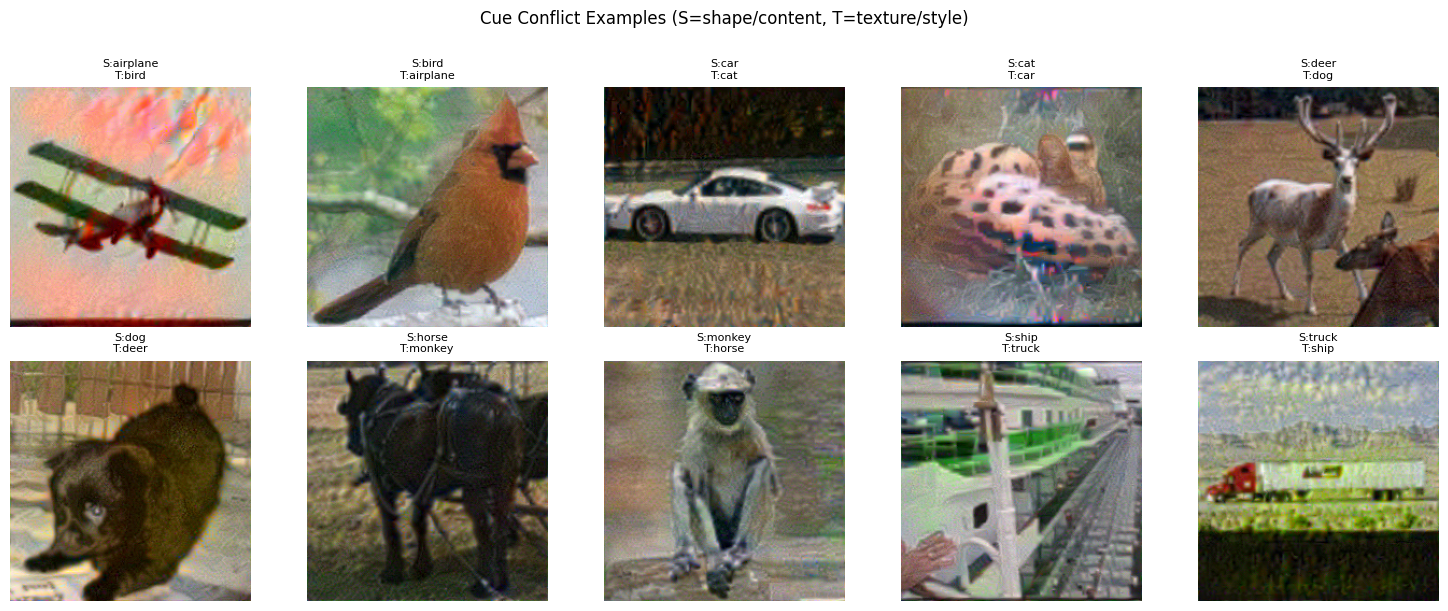

In [11]:
n = len(conflict_images)
step = max(n // 10, 1)
fig, axs = plt.subplots(2, 5, figsize=(15, 6))
for i in range(10):
    ax = axs[i // 5, i % 5]
    idx = i * step
    ax.imshow(conflict_images[idx].permute(1, 2, 0).clamp(0, 1))
    s = class_names[conflict_shape_labels[idx]]
    t = class_names[conflict_texture_labels[idx]]
    ax.set_title(f"S:{s}\nT:{t}", fontsize=8)
    ax.axis('off')
plt.suptitle('Cue Conflict Examples (S=shape/content, T=texture/style)', y=1.01)
plt.tight_layout()
plt.savefig('figures/task1_cue_conflict_examples.png', dpi=150, bbox_inches='tight')
plt.show()


In [12]:
class ConflictDataset(torch.utils.data.Dataset):
    def __init__(self, imgs, s_labels, t_labels):
        self.imgs, self.s, self.t = imgs, s_labels, t_labels
    def __len__(self): return len(self.imgs)
    def __getitem__(self, i): return self.imgs[i], self.s[i], self.t[i]

conflict_loader = DataLoader(
    ConflictDataset(conflict_images, conflict_shape_labels, conflict_texture_labels),
    batch_size=32
)

conflict_results = {m: [] for m in ['resnet','vit','clip','clip_zs']}
for name in ['resnet','vit','clip']: heads[name].eval()

with torch.no_grad():
    for x, s_y, t_y in tqdm(conflict_loader, desc='Evaluating conflicts'):
        for name in ['resnet','vit','clip']:
            fe, norm, _ = models_dict[name]
            pred = heads[name](fe(norm(x).to(device))).argmax(1).cpu()
            for p, s, t in zip(pred, s_y, t_y):
                conflict_results[name].append((p.item(), s.item(), t.item()))

        _, norm, _ = models_dict['clip']
        img_f = clip_model.encode_image(norm(x).to(device))
        img_f = img_f / img_f.norm(dim=-1, keepdim=True)
        pred  = (100.0 * img_f @ text_features.T).argmax(1).cpu()
        for p, s, t in zip(pred, s_y, t_y):
            conflict_results['clip_zs'].append((p.item(), s.item(), t.item()))

conflict_metrics = []
for model, res in conflict_results.items():
    n_shape   = sum(1 for p,s,t in res if p == s)
    n_texture = sum(1 for p,s,t in res if p == t)
    n_total   = len(res)
    conflict_metrics.append({
        'Model':          model,
        'Shape Bias (%)': round(n_shape / (n_shape + n_texture + 1e-8) * 100, 2),
        'Coverage (%)':   round((n_shape + n_texture) / n_total * 100, 2),
        'N_shape':        n_shape,
        'N_texture':      n_texture,
        'N_other':        n_total - n_shape - n_texture,
    })

df_conflict = pd.DataFrame(conflict_metrics)
df_conflict.to_csv('results/task1_shape_texture.csv', index=False)
display(df_conflict)


Evaluating conflicts:   0%|          | 0/7 [00:00<?, ?it/s]

,Model,Shape Bias (%),Coverage (%),N_shape,N_texture,N_other
0,resnet,97.87,94.0,184,4,12
1,vit,98.42,95.0,187,3,10
2,clip,98.90,90.5,179,2,19
3,clip_zs,98.34,90.5,178,3,19


## 4. Translation


Displacement: 0px
Displacement: 8px


Evaluating:   0%|          | 0/16 [00:00<?, ?it/s]

Evaluating:   0%|          | 0/16 [00:00<?, ?it/s]

Evaluating:   0%|          | 0/16 [00:00<?, ?it/s]

Evaluating:   0%|          | 0/16 [00:00<?, ?it/s]

...

Displacement: 32px


Evaluating:   0%|          | 0/16 [00:00<?, ?it/s]

Evaluating:   0%|          | 0/16 [00:00<?, ?it/s]

Evaluating:   0%|          | 0/16 [00:00<?, ?it/s]

Evaluating:   0%|          | 0/16 [00:00<?, ?it/s]

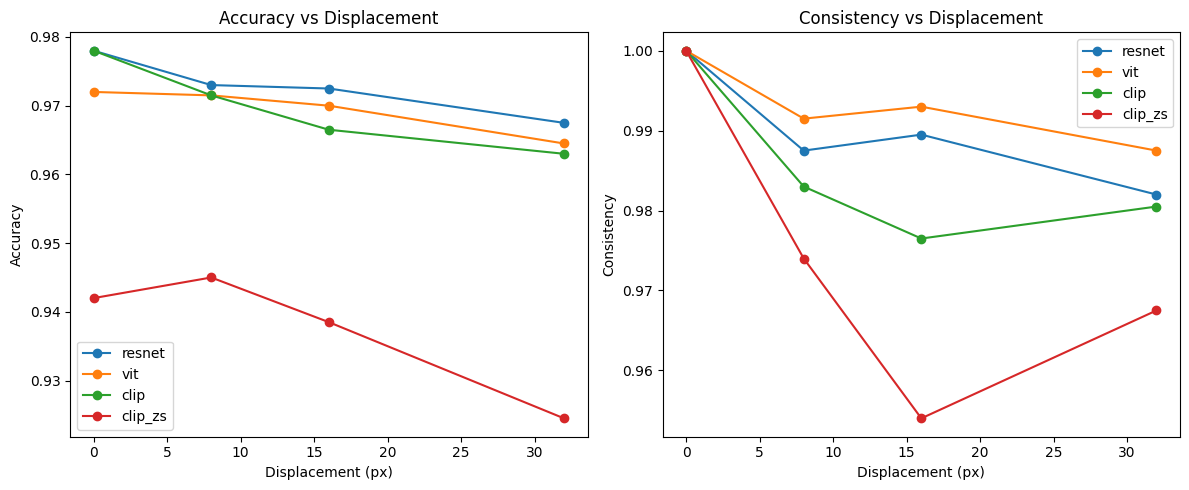

In [13]:
def translate_image(x, dx, dy):
    pad     = transforms.Pad((abs(dx), abs(dy)), padding_mode='reflect')
    x_pad   = pad(x)
    _, h, w = x.shape
    start_y = abs(dy) - dy
    start_x = abs(dx) - dx
    return TF.crop(x_pad, start_y, start_x, h, w)

displacements = [0, 8, 16, 32]
directions    = [(0, 1), (0, -1), (1, 0), (-1, 0)]
trans_results = []

for d in displacements:
    print(f"Displacement: {d}px")
    if d == 0:
        for model in clean_results:
            acc = accuracy_score(clean_results[model]['y_true'], clean_results[model]['y_pred'])
            trans_results.append({'Model': model, 'Displacement': 0,
                                  'Accuracy': acc, 'Consistency': 1.0})
        continue

    model_preds_d = {m: [] for m in ['resnet','vit','clip','clip_zs']}
    model_accs_d  = {m: [] for m in ['resnet','vit','clip','clip_zs']}

    for dx, dy in directions:
        def t_fn(x, _dx=dx, _dy=dy, _d=d):
            return torch.stack([translate_image(img, _dx * _d, _dy * _d) for img in x])
        res = evaluate_models(test_loader, transform_fn=t_fn)
        for model in res:
            model_preds_d[model].append(res[model]['y_pred'])
            model_accs_d[model].append(accuracy_score(res[model]['y_true'], res[model]['y_pred']))

    for model in model_preds_d:
        avg_acc  = np.mean(model_accs_d[model])
        cons_arr = [np.mean(np.array(model_preds_d[model][i]) ==
                            np.array(clean_results[model]['y_pred'])) for i in range(4)]
        trans_results.append({'Model': model, 'Displacement': d,
                              'Accuracy': avg_acc, 'Consistency': np.mean(cons_arr)})

df_trans = pd.DataFrame(trans_results)
df_trans.to_csv('results/task1_translation.csv', index=False)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
for model in df_trans['Model'].unique():
    sub = df_trans[df_trans['Model'] == model]
    ax1.plot(sub['Displacement'], sub['Accuracy'],    marker='o', label=model)
    ax2.plot(sub['Displacement'], sub['Consistency'], marker='o', label=model)
for ax, ylabel, title in [(ax1, 'Accuracy', 'Accuracy vs Displacement'),
                           (ax2, 'Consistency', 'Consistency vs Displacement')]:
    ax.set_xlabel('Displacement (px)')
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    ax.legend()
plt.tight_layout()
plt.savefig('figures/task1_translation_curve.png', dpi=150)
plt.show()


## 5. Patch Structure


In [14]:
_patch_rng = torch.Generator()
_patch_rng.manual_seed(SEED)
PATCH_PERMS = []
for _ in range(600):
    perm = torch.randperm(16, generator=_patch_rng)
    while torch.all(perm == torch.arange(16)):
        perm = torch.randperm(16, generator=_patch_rng)
    PATCH_PERMS.append(perm)
_pci = [0]  # global counter; reset to 0 before each evaluation pass

def patch_shuffle(x):
    B, C, H, W = x.shape
    ph, pw = H // 4, W // 4
    out = torch.zeros_like(x)
    for i in range(B):
        perm = PATCH_PERMS[_pci[0] % len(PATCH_PERMS)]
        _pci[0] += 1
        patches = [x[i, :, r*ph:(r+1)*ph, c*pw:(c+1)*pw]
                   for r in range(4) for c in range(4)]
        shuffled = [patches[perm[j]] for j in range(16)]
        for j, patch in enumerate(shuffled):
            r, c = j // 4, j % 4
            out[i, :, r*ph:(r+1)*ph, c*pw:(c+1)*pw] = patch
    return out

_pci[0] = 0
patch_results = evaluate_models(test_loader, transform_fn=patch_shuffle)

patch_metrics = []
for model in clean_results:
    clean_acc  = df_baseline[df_baseline['Model'] == model]['Accuracy'].values[0]
    patch_acc  = accuracy_score(patch_results[model]['y_true'], patch_results[model]['y_pred'])
    patch_cons = np.mean(np.array(patch_results[model]['y_pred']) ==
                         np.array(clean_results[model]['y_pred']))
    patch_metrics.append({
        'Model':         model,
        'Accuracy Drop': round(clean_acc - patch_acc, 4),
        'Consistency':   round(patch_cons, 4),
    })

df_patch = pd.DataFrame(patch_metrics)
df_patch.to_csv('results/task1_patch_shuffle.csv', index=False)
display(df_patch)


Evaluating:   0%|          | 0/16 [00:00<?, ?it/s]

,Model,Accuracy Drop,Consistency
0,resnet,0.066,0.922
1,vit,0.072,0.922
2,clip,0.174,0.816
3,clip_zs,0.154,0.798


## 6. Representation Analysis


In [15]:
def get_features(loader, model_name, transform_fn=None):
    fe, norm, _ = models_dict[model_name]
    fe.eval()
    feats = []
    with torch.no_grad():
        for x, _ in loader:
            if transform_fn: x = transform_fn(x)
            feats.append(fe(norm(x).to(device)).cpu())
    return torch.cat(feats)

def calc_stability(f1, f2):
    n1 = f1 / f1.norm(dim=1, keepdim=True)
    n2 = f2 / f2.norm(dim=1, keepdim=True)
    return (n1 * n2).sum(1).mean().item()

def t32_fn(x):
    return torch.stack([translate_image(img, 32, 0) for img in x])

transforms_stab = {
    'Grayscale':        grayscale_transform,
    'Translation 32px': t32_fn,
    'Patch Shuffle':    patch_shuffle,
}

stability_results = []

for model in ['resnet', 'vit', 'clip']:
    f_clean = get_features(test_loader, model)

    for t_name, t_fn in transforms_stab.items():
        if t_name == 'Patch Shuffle':
            _pci[0] = 0
        f_t = get_features(test_loader, model, transform_fn=t_fn)
        stability_results.append({
            'Model': model, 'Transform': t_name,
            'Cosine Stability': round(calc_stability(f_clean, f_t), 4),
        })

    fe, norm, _ = models_dict[model]
    fe.eval()
    c_feats, k_feats = [], []
    with torch.no_grad():
        for c_img, k_img in zip(conflict_content_imgs, conflict_images):
            c_feats.append(fe(norm(c_img.unsqueeze(0)).to(device)).cpu())
            k_feats.append(fe(norm(k_img.unsqueeze(0)).to(device)).cpu())
    stability_results.append({
        'Model': model, 'Transform': 'Cue Conflict',
        'Cosine Stability': round(
            calc_stability(torch.cat(c_feats), torch.cat(k_feats)), 4),
    })

df_stab = pd.DataFrame(stability_results)
df_stab.to_csv('results/task1_cosine_stability.csv', index=False)
display(df_stab)


,Model,Transform,Cosine Stability
0,resnet,Grayscale,0.8036
1,resnet,Translation 32px,0.9202
2,resnet,Patch Shuffle,0.6991
3,resnet,Cue Conflict,0.7024
4,vit,Grayscale,0.7331
5,vit,Translation 32px,0.9491
6,vit,Patch Shuffle,0.6322
7,vit,Cue Conflict,0.6714
8,clip,Grayscale,0.8859
9,clip,Translation 32px,0.9600


/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


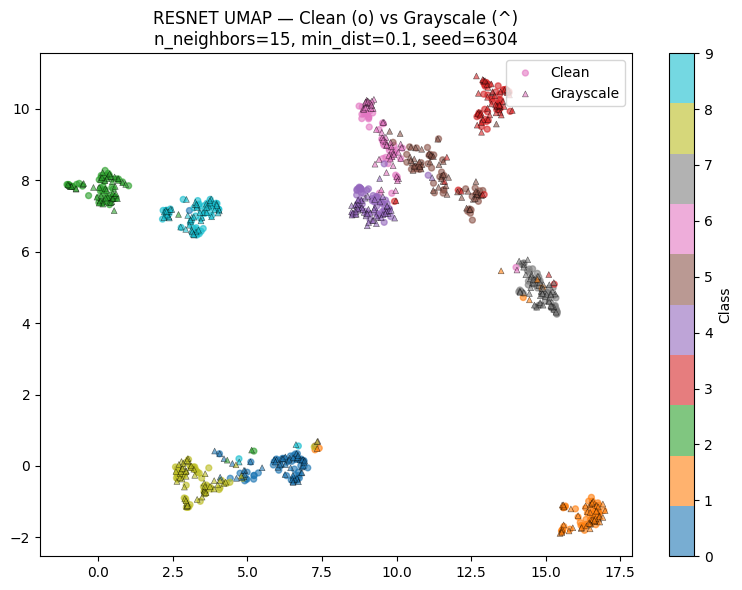

/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


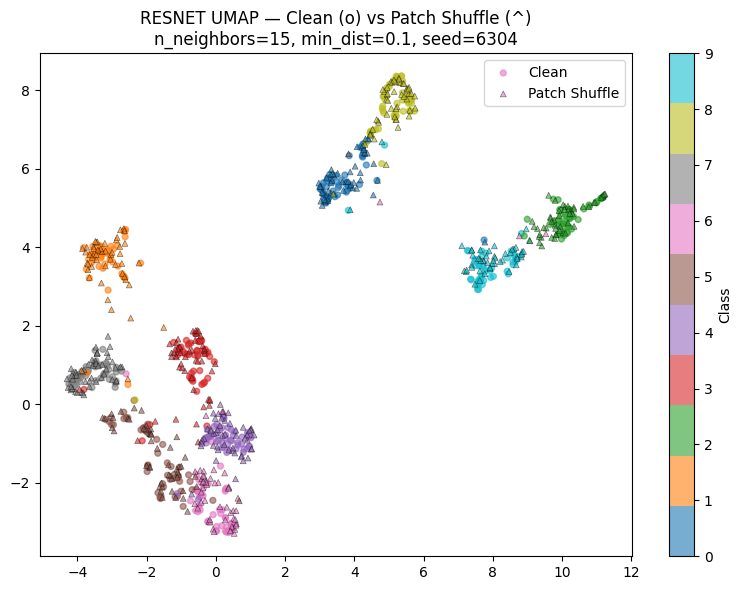

/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


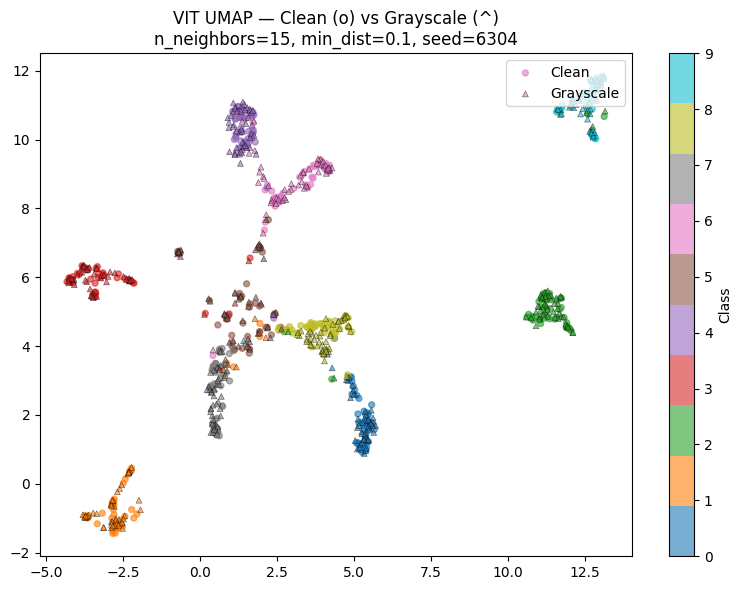

/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


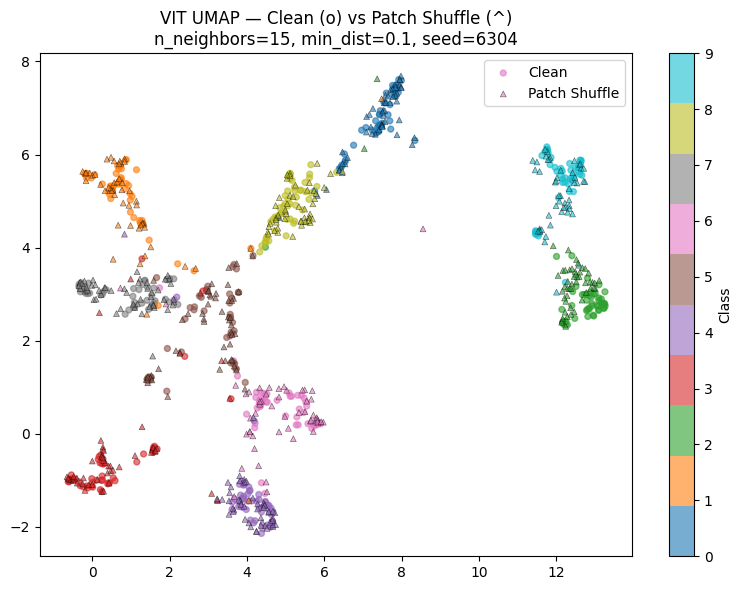

/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


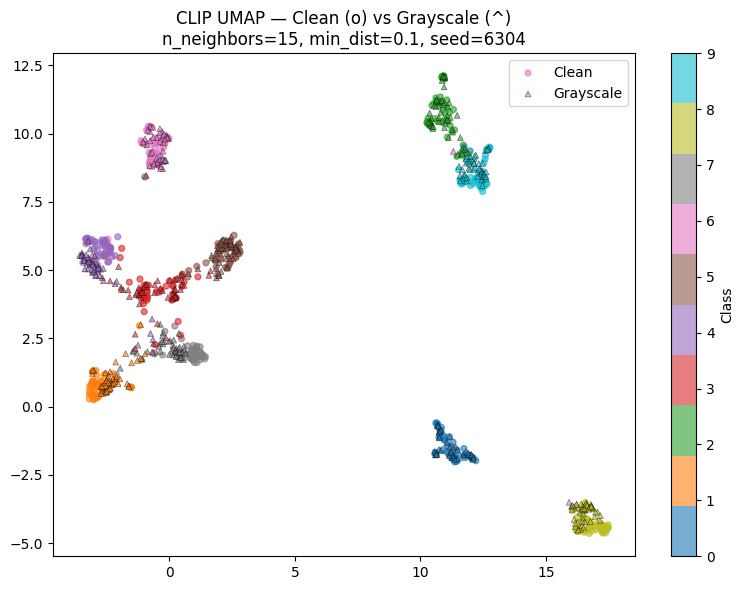

/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


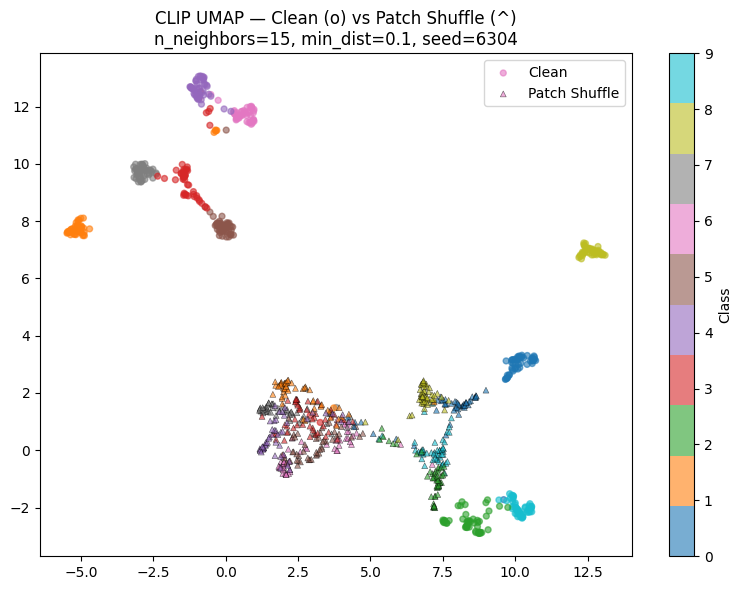

In [16]:
labels_test = np.array(clean_results['resnet']['y_true'])

umap_transforms = {
    'Grayscale':     grayscale_transform,
    'Patch Shuffle': patch_shuffle,
}

for model in ['resnet', 'vit', 'clip']:
    f_clean = get_features(test_loader, model).numpy()

    for t_label, t_fn in umap_transforms.items():
        if t_label == 'Patch Shuffle':
            _pci[0] = 0
        f_t = get_features(test_loader, model, transform_fn=t_fn).numpy()

        combined  = np.vstack([f_clean, f_t])
        comb_lbls = np.concatenate([labels_test, labels_test])
        is_t      = np.array([0]*len(f_clean) + [1]*len(f_t))

        reducer = umap.UMAP(n_components=2, n_neighbors=15, min_dist=0.1, random_state=SEED)
        proj    = reducer.fit_transform(combined)

        slug = t_label.lower().replace(' ', '_')
        fig, ax = plt.subplots(figsize=(8, 6))
        sc = ax.scatter(proj[is_t==0, 0], proj[is_t==0, 1],
                        c=comb_lbls[is_t==0], cmap='tab10',
                        marker='o', alpha=0.6, s=18, label='Clean')
        ax.scatter(proj[is_t==1, 0], proj[is_t==1, 1],
                   c=comb_lbls[is_t==1], cmap='tab10',
                   marker='^', alpha=0.6, s=18,
                   edgecolors='k', linewidths=0.4, label=t_label)
        plt.colorbar(sc, ticks=range(10), label='Class')
        ax.set_title(f'{model.upper()} UMAP — Clean (o) vs {t_label} (^)\n'
                     f'n_neighbors=15, min_dist=0.1, seed={SEED}')
        ax.legend(loc='upper right')
        plt.tight_layout()
        plt.savefig(f'figures/task1_umap_{model}_{slug}.png', dpi=150)
        plt.show()


## Cleanup


In [17]:
import shutil

shutil.rmtree('./data', ignore_errors=True)

for name in ['resnet', 'vit', 'clip']:
    p = f'results/{name}_head.pt'
    if os.path.exists(p):
        os.remove(p)

print("Done: STL-10 binaries and model weights removed.")


Done: STL-10 binaries and model weights removed.
